CIFAR10

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

# ------------------------------
# Configuration
# ------------------------------
batch_size = 32

# ------------------------------
# Training data preprocessing
# ------------------------------
def _fn_train(img, label):
    """
    Preprocess a training image:
    - Convert to float32
    - Random crop to 24x24
    - Random horizontal flip
    """
    img = tf.cast(img, tf.float32)
    img = tf.image.random_crop(img, size=[24, 24, 3])
    img = tf.image.random_flip_left_right(img)
    mean = tf.reduce_mean(img)
    std = tf.math.reduce_std(img)
    img = (img - mean) / (std + 1e-7)  # Avoid division by zero
    label = tf.reshape(label, ())
    return img, label

# ------------------------------
# Test/validation data preprocessing
# ------------------------------
def _fn_test(img, label):
    """
    Preprocess a test image:
    - Convert to float32
    - Center crop to 24x24
    """
    img = tf.cast(img, tf.float32)
    # Center crop: take middle 24x24 region
    img = tf.image.resize_with_crop_or_pad(img, target_height=24, target_width=24)
    mean = tf.reduce_mean(img)
    std = tf.math.reduce_std(img)
    img = (img - mean) / (std + 1e-7)
    label = tf.reshape(label, ())
    return img, label

# ------------------------------
# Load CIFAR-10 dataset
# ------------------------------
print("Loading and preprocessing CIFAR-10 dataset...")
train_ds = tfds.load('cifar10', split='train', as_supervised=True)
test_ds = tfds.load('cifar10', split='test', as_supervised=True)

# ------------------------------
# Build input pipelines
# ------------------------------
train_ds = (
    train_ds
    .map(_fn_train, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(buffer_size=50000)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .map(_fn_test, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# ------------------------------
# Define CNN model
# ------------------------------
def get_model_batchnorm(input_shape):
    W_init = tf.keras.initializers.TruncatedNormal(stddev=5e-2)
    W_init2 = tf.keras.initializers.TruncatedNormal(stddev=0.04)
    b_init2 = tf.keras.initializers.Constant(value=0.1)

    inputs = tf.keras.Input(shape=input_shape)
    x = inputs

    # Block 1
    x = tf.keras.layers.Conv2D(64, (5, 5), padding='same', kernel_initializer=W_init, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization(momentum=0.99)(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Block 2
    x = tf.keras.layers.Conv2D(64, (5, 5), padding='same', kernel_initializer=W_init, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization(momentum=0.99)(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Classifier
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(384, activation='relu', kernel_initializer=W_init2, bias_initializer=b_init2)(x)
    x = tf.keras.layers.Dense(192, activation='relu', kernel_initializer=W_init2, bias_initializer=b_init2)(x)
    outputs = tf.keras.layers.Dense(10, kernel_initializer=W_init2, bias_initializer=b_init2)(x)  # logits

    return tf.keras.Model(inputs=inputs, outputs=outputs, name='cnn_batchnorm')

# ------------------------------
# Create and compile model
# ------------------------------
model = get_model_batchnorm(input_shape=(24, 24, 3))

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

# ------------------------------
# Train the model
# ------------------------------
print("\n🚀 Starting training...")
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=test_ds,
    verbose=1
)

print("\n✅ Training completed successfully!")

Loading and preprocessing CIFAR-10 dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 24, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 24, 24, 64)     │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │       102,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 384)            │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 192)            │        73,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,068,682 (4.08 MB)

 Trainable params: 1,068,426 (4.08 MB)

 Non-trainable params: 256 (1.00 KB)


🚀 Starting training...
Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step - accuracy: 0.3818 - loss: 1.6713 - val_accuracy: 0.6003 - val_loss: 1.1184
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.5668 - loss: 1.2178 - val_accuracy: 0.6354 - val_loss: 1.0563
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6257 - loss: 1.0652 - val_accuracy: 0.6670 - val_loss: 0.9208
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6563 - loss: 0.9784 - val_accuracy: 0.6880 - val_loss: 0.9030
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.6743 - loss: 0.9270 - val_accuracy: 0.7182 - val_loss: 0.8266
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6931 - loss: 0.8724 - val_accuracy: 0.7260 - val_loss: 0.7868
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7075 - loss: 0.8452 - val_accuracy: 0.7385 - val_loss: 0.7513
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - ac

customize model

Loading and preparing CIFAR-10 data...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step

✅ Model Architecture:


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 24, 24, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       204,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,704,074 (10.32 MB)

 Trainable params: 2,703,690 (10.31 MB)

 Non-trainable params: 384 (1.50 KB)


🚀 Starting training for up to 50 epochs...
Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.2118 - loss: 2.1646 - val_accuracy: 0.4098 - val_loss: 1.5696
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.3647 - loss: 1.6982 - val_accuracy: 0.4770 - val_loss: 1.4367
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4294 - loss: 1.5663 - val_accuracy: 0.5497 - val_loss: 1.3328
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.4765 - loss: 1.4696 - val_accuracy: 0.5751 - val_loss: 1.2188
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5050 - loss: 1.3971 - val_accuracy: 0.6122 - val_loss: 1.1303
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5327 - loss: 1.3258 - val_accuracy: 0.6427 - val_loss: 1.0790
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5538 - loss: 1.2704 - val_accuracy: 0.6419 - val_loss: 1.0728
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step -

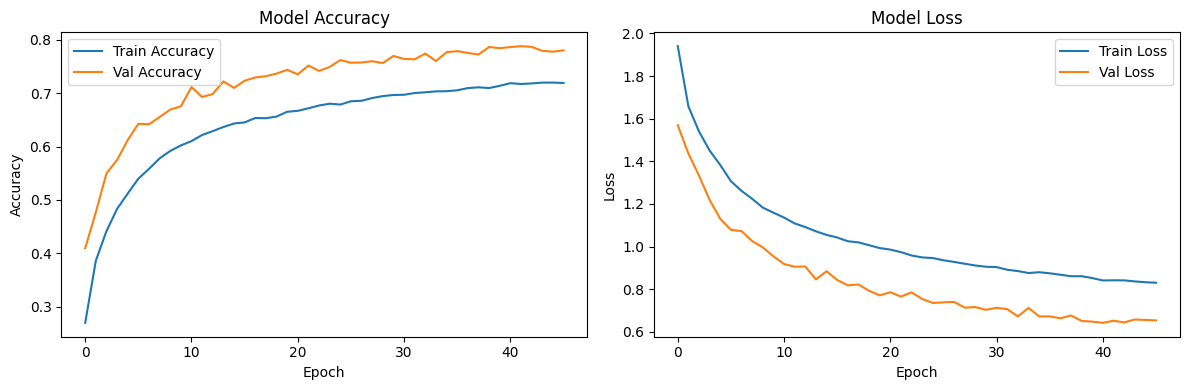


📊 Generating Confusion Matrix...
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


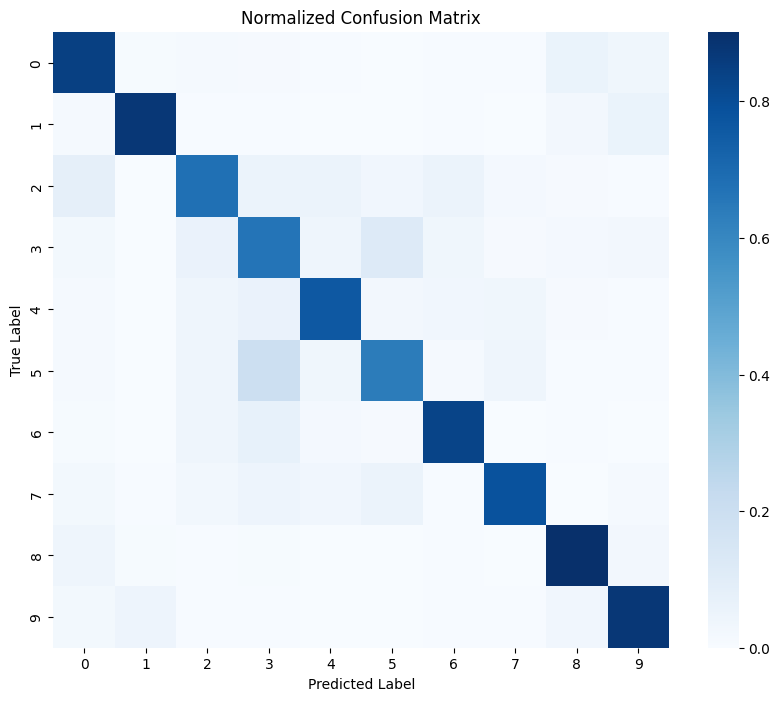


🖼️ Displaying Sample Images with Predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step


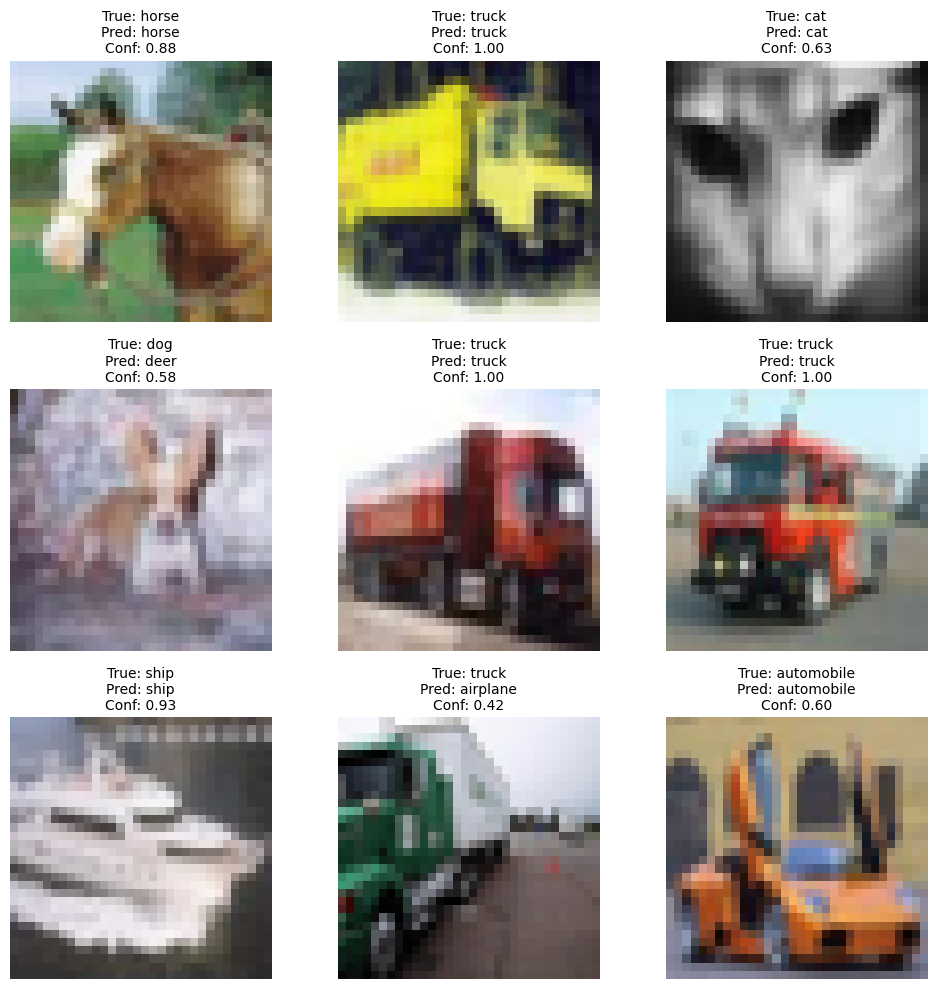

📊 Training plots saved as 'training_history.png'
🧩 Confusion matrix saved as 'confusion_matrix.png'
🖼️ Sample predictions saved as 'sample_predictions.png'
📉 TensorBoard logs saved to: logs/fit/20251112-165657

To view TensorBoard, run in terminal:
tensorboard --logdir /content/logs/fit/20251112-165657


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import datetime
import os

# ------------------------------
# Configuration
# ------------------------------
BATCH_SIZE = 64
NUM_CLASSES = 10
EPOCHS = 50  # Increased to allow EarlyStopping to work
FINAL_CROP_SHAPE = (24, 24, 3)

# Model architecture parameters
CONV_FILTERS = [64, 128]  # Number of filters in each conv block
DENSE_UNITS = [512, 256]  # Units in dense layers (before final output)

# ------------------------------
# 1. Data Loading and Preprocessing
# ------------------------------
print("Loading and preparing CIFAR-10 data...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Keep labels as integers (not one-hot) for sparse loss
y_train = y_train.squeeze()  # shape: (50000,)
y_test = y_test.squeeze()     # shape: (10000,)

def apply_augmentation_and_norm(img, label):
    img = tf.cast(img, tf.float32)
    img = tf.image.random_crop(img, size=[24, 24, 3])
    img = tf.image.random_flip_left_right(img)
    mean = tf.reduce_mean(img)
    std = tf.math.reduce_std(img)
    img = (img - mean) / (std + 1e-7)
    return img, label

def apply_norm_only(img, label):
    img = tf.cast(img, tf.float32)
    img = tf.image.resize_with_crop_or_pad(img, 24, 24)  # center crop
    mean = tf.reduce_mean(img)
    std = tf.math.reduce_std(img)
    img = (img - mean) / (std + 1e-7)
    return img, label

# Build datasets
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dl = (
    train_ds
    .shuffle(10000)
    .map(apply_augmentation_and_norm, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dl = (
    test_ds
    .map(apply_norm_only, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ------------------------------
# 2. Model Definition (Customizable)
# ------------------------------
def get_cnn_model(input_shape, conv_filters, dense_units, num_classes=10):
    W_init_conv = tf.keras.initializers.TruncatedNormal(stddev=5e-2)
    W_init_dense = tf.keras.initializers.TruncatedNormal(stddev=0.04)
    b_init_dense = tf.keras.initializers.Constant(value=0.1)

    inputs = tf.keras.Input(shape=input_shape)
    x = inputs

    # Convolutional blocks
    for i, filters in enumerate(conv_filters):
        x = tf.keras.layers.Conv2D(
            filters=filters,
            kernel_size=5,
            padding='same',
            kernel_initializer=W_init_conv,
            use_bias=False
        )(x)
        x = tf.keras.layers.BatchNormalization(momentum=0.99)(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)
        if i == 0:  # Add dropout after first conv block
            x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dropout(0.5)(x)  # Dropout before dense layers

    # Dense layers
    for units in dense_units:
        x = tf.keras.layers.Dense(
            units,
            activation='relu',
            kernel_initializer=W_init_dense,
            bias_initializer=b_init_dense
        )(x)
        x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(
        num_classes,
        activation=None,
        kernel_initializer=W_init_dense,
        bias_initializer=b_init_dense
    )(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name='custom_cnn')

model = get_cnn_model(
    input_shape=FINAL_CROP_SHAPE,
    conv_filters=CONV_FILTERS,
    dense_units=DENSE_UNITS,
    num_classes=NUM_CLASSES
)

print("\n✅ Model Architecture:")
model.summary()

# ------------------------------
# 3. Callbacks Setup
# ------------------------------
# Create log directory for TensorBoard
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir, histogram_freq=1
)

# Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# List of callbacks
callbacks = [tensorboard_callback, early_stopping]

# ------------------------------
# 4. Compile and Train
# ------------------------------
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f"\n🚀 Starting training for up to {EPOCHS} epochs...")
history = model.fit(
    train_dl,
    epochs=EPOCHS,
    validation_data=test_dl,
    callbacks=callbacks,
    verbose=1
)

# ------------------------------
# 5. Final Test Accuracy
# ------------------------------
test_loss, test_accuracy = model.evaluate(test_dl, verbose=0)
print(f"\n🎯 Final Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# ------------------------------
# 6. Plot Training History
# ------------------------------
def plot_training_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy
    ax[0].plot(history.history['accuracy'], label='Train Accuracy')
    ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    ax[0].set_title('Model Accuracy')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()

    # Loss
    ax[1].plot(history.history['loss'], label='Train Loss')
    ax[1].plot(history.history['val_loss'], label='Val Loss')
    ax[1].set_title('Model Loss')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Loss')
    ax[1].legend()

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    plt.show()

plot_training_history(history)

# ------------------------------
# 7. Confusion Matrix
# ------------------------------
print("\n📊 Generating Confusion Matrix...")
# Get predictions
y_pred_logits = model.predict(test_dl)
y_pred = np.argmax(y_pred_logits, axis=1)

# Flatten true labels
y_true = y_test  # shape (10000,)

cm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', square=True)
plt.title('Normalized Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ------------------------------
# 8. Display Sample Images with Predictions
# ------------------------------
print("\n🖼️ Displaying Sample Images with Predictions...")

# Get a few test images (original size 32x32)
sample_indices = np.random.choice(len(x_test), 9, replace=False)
sample_images = x_test[sample_indices]
sample_true_labels = y_test[sample_indices]

# Preprocess for model (24x24 + norm)
def preprocess_for_model(img):
    img = tf.cast(img, tf.float32)
    img = tf.image.resize_with_crop_or_pad(img, 24, 24)
    mean = tf.reduce_mean(img)
    std = tf.math.reduce_std(img)
    img = (img - mean) / (std + 1e-7)
    return img

preprocessed = np.array([preprocess_for_model(img) for img in sample_images])
predictions = model.predict(preprocessed)
predicted_labels = np.argmax(predictions, axis=1)
confidence = np.max(tf.nn.softmax(predictions), axis=1)

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Plot
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.ravel()

for i in range(9):
    # Display original 32x32 image
    axes[i].imshow(sample_images[i])
    axes[i].set_title(
        f'True: {class_names[sample_true_labels[i]]}\n'
        f'Pred: {class_names[predicted_labels[i]]}\n'
        f'Conf: {confidence[i]:.2f}',
        fontsize=10
    )
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()

print(f"📊 Training plots saved as 'training_history.png'")
print(f"🧩 Confusion matrix saved as 'confusion_matrix.png'")
print(f"🖼️ Sample predictions saved as 'sample_predictions.png'")
print(f"📉 TensorBoard logs saved to: {log_dir}")
print("\nTo view TensorBoard, run in terminal:")
print(f"tensorboard --logdir {os.path.abspath(log_dir)}")

Coin Classifier

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import datetime
import os

# ------------------------------
# Configuration
# ------------------------------
BATCH_SIZE = 64
NUM_CLASSES = 10  # CIFAR-10 has 10 classes
EPOCHS = 30  # Enough for decent pre-training
IMG_SIZE = 32  # Original CIFAR-10 size
SAVE_DIR = "pretrained_cifar10"

# ------------------------------
# 1. Data Loading and Preprocessing (Standard Normalization)
# ------------------------------
print("Loading and preparing CIFAR-10 data...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Convert labels to 1D
y_train = y_train.squeeze()
y_test = y_test.squeeze()

# Standard normalization: [0, 255] → [0, 1]
def normalize_img(img, label):
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment_and_normalize(img, label):
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_crop(img, size=[IMG_SIZE, IMG_SIZE, 3])  # crop back to 32x32 (identity if no resize)
    return img, label

# Build datasets
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dl = (
    train_ds
    .shuffle(10000)
    .map(augment_and_normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dl = (
    test_ds
    .map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ------------------------------
# 2. Model Definition (Designed for Reuse)
# ------------------------------
def build_cifar_backbone(input_shape=(32, 32, 3), num_classes=10):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs

    # Block 1
    x = tf.keras.layers.Conv2D(64, 5, padding='same', kernel_initializer='he_uniform')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D(3, strides=2, padding='same')(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(128, 5, padding='same', kernel_initializer='he_uniform')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D(3, strides=2, padding='same')(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Feature extractor (will be reused)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(512, activation='relu', kernel_initializer='he_uniform')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    # Final classifier (will be replaced for coins)
    outputs = tf.keras.layers.Dense(num_classes, activation=None, name='logits')(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name='cifar_pretrained')

model = build_cifar_backbone()

# ------------------------------
# 3. Compile and Train
# ------------------------------
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

print(f"\n🚀 Pre-training on CIFAR-10 for up to {EPOCHS} epochs...")
history = model.fit(
    train_dl,
    epochs=EPOCHS,
    validation_data=test_dl,
    callbacks=callbacks,
    verbose=1
)

# ------------------------------
# 4. Evaluate and Save
# ------------------------------
test_loss, test_acc = model.evaluate(test_dl, verbose=0)
print(f"\n✅ CIFAR-10 Pre-training Test Accuracy: {test_acc:.4f}")

# Create save directory
os.makedirs(SAVE_DIR, exist_ok=True)

# ✅ Save full model for later reuse (weights + architecture)
model.save(os.path.join(SAVE_DIR, "cifar10_pretrained.h5"))
print(f"✅ Pre-trained model saved to: {SAVE_DIR}/cifar10_pretrained.h5")

# Optional: Save only backbone (without classifier) for transfer
backbone = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer('logits').output  # or last hidden layer if you prefer
)
backbone.save(os.path.join(SAVE_DIR, "cifar10_backbone.h5"))

Loading and preparing CIFAR-10 data...

🚀 Pre-training on CIFAR-10 for up to 30 epochs...
Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.2247 - loss: 2.9185 - val_accuracy: 0.4151 - val_loss: 1.5531 - learning_rate: 0.0010
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.3278 - loss: 1.7150 - val_accuracy: 0.4499 - val_loss: 1.4482 - learning_rate: 0.0010
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3647 - loss: 1.6142 - val_accuracy: 0.5162 - val_loss: 1.3135 - learning_rate: 0.0010
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3941 - loss: 1.5634 - val_accuracy: 0.5525 - val_loss: 1.2778 - learning_rate: 0.0010
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4113 - loss: 1.5164 - val_accuracy: 0.5209 - val_loss: 1.3569 - learning_rate: 0.0010
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4304 - loss: 1.4765 - val_accuracy: 0.5784 - val_loss: 1.1951 - learning_rat


✅ CIFAR-10 Pre-training Test Accuracy: 0.7936
✅ Pre-trained model saved to: pretrained_cifar10/cifar10_pretrained.h5


In [ ]:
# Load pre-trained model
base_model = tf.keras.models.load_model("pretrained_cifar10/cifar10_pretrained.h5")

# Freeze base (optional)
base_model.trainable = False

# Add new head for coins
coin_model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Dense(6, activation=None, name='coin_logits')
])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ------------------------------
# Configuration
# ------------------------------
BATCH_SIZE = 32
IMG_SIZE = 32  # Must match CIFAR-10 model input
NUM_COIN_CLASSES = 6

# 🔁 Update these paths to YOUR Google Drive structure
ZIP_PATH = "/content/drive/MyDrive/Reinforcement Learning/archive (1).zip"        # Path to your ZIP file
PRETRAINED_MODEL_PATH = "pretrained_cifar10/cifar10_pretrained.h5"

# Temporary extraction path (in Colab VM)
EXTRACT_TO = "/content/coin_dataset"
OUTPUT_DIR = "/content/drive/MyDrive/coin_finetuned_model"

# ------------------------------
# 1. Extract ZIP file
# ------------------------------
print(f"\n📦 Extracting dataset from: {ZIP_PATH}")

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"ZIP file not found at: {ZIP_PATH}")

os.makedirs(EXTRACT_TO, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_TO)

print(f"✅ Dataset extracted to: {EXTRACT_TO}")

# Expected structure after extraction:
# /content/coin_dataset/
#   ├── train/
#   │   ├── 1000/
#   │   └── ...
#   └── validation/ (or you can split later)

# Optional: Check extracted structure
print("\n📁 Extracted folders:")
for root, dirs, files in os.walk(EXTRACT_TO):
    level = root.replace(EXTRACT_TO, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for d in dirs[:3]:  # Show only first 3 subdirs
        print(f"{subindent}{d}/")
    if level > 2:  # Avoid printing too deep
        break



📦 Extracting dataset from: /content/drive/MyDrive/Reinforcement Learning/archive (1).zip
✅ Dataset extracted to: /content/coin_dataset

📁 Extracted folders:
coin_dataset/
  coins/
  coins/
    data/
    data/
      test/
      train/
      validation/
      test/
        79/
        1/
        84/


In [ ]:
# ------------------------------
# 1.5 Auto-detect and fix dataset structure
# ------------------------------
print("\n🔍 Analyzing extracted folder structure...")

extracted_items = os.listdir(EXTRACT_TO)
print(f"Top-level items in {EXTRACT_TO}: {extracted_items}")

# Case 1: If there's only ONE subfolder, go inside it (common with Kaggle ZIPs)
if len(extracted_items) == 1:
    potential_root = os.path.join(EXTRACT_TO, extracted_items[0])
    if os.path.isdir(potential_root):
        print(f"📁 Going into subfolder: {potential_root}")
        EXTRACT_TO = potential_root
        extracted_items = os.listdir(EXTRACT_TO)

# Check if top-level contains class folders (e.g., '1000', '2000')
first_item = extracted_items[0] if extracted_items else None
class_folders = [f for f in extracted_items if os.path.isdir(os.path.join(EXTRACT_TO, f))]

# Guess: if first folder name is numeric → it's a class folder → we need to wrap in 'train'
if class_folders and first_item.isdigit():
    print("📁 Detected class folders at root. Creating 'train' directory...")
    train_wrapper = os.path.join(EXTRACT_TO + "_wrapped", "train")
    os.makedirs(train_wrapper, exist_ok=True)

    # Move all class folders into 'train'
    for folder in class_folders:
        src = os.path.join(EXTRACT_TO, folder)
        dst = os.path.join(train_wrapper, folder)
        os.rename(src, dst)

    EXTRACT_TO = os.path.dirname(train_wrapper)  # now points to ..._wrapped

print(f"✅ Final dataset root: {EXTRACT_TO}")


🔍 Analyzing extracted folder structure...
Top-level items in /content/coin_dataset: ['coins', 'cat_to_name.json']
✅ Final dataset root: /content/coin_dataset


In [ ]:
# ------------------------------
# 1. Extract ZIP file
# ------------------------------
print(f"\n📦 Extracting dataset from: {ZIP_PATH}")

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"ZIP file not found at: {ZIP_PATH}")

os.makedirs(EXTRACT_TO, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_TO)

print(f"✅ Dataset extracted to: {EXTRACT_TO}")

# ------------------------------
# 1.5 Auto-detect and fix dataset structure
# ------------------------------
print("\n🔍 Analyzing extracted folder structure...")

extracted_items = os.listdir(EXTRACT_TO)
print(f"Top-level items: {extracted_items}")

# Handle single-root-folder ZIPs (e.g., Kaggle)
if len(extracted_items) == 1:
    potential_root = os.path.join(EXTRACT_TO, extracted_items[0])
    if os.path.isdir(potential_root):
        print(f"📁 Using subfolder: {potential_root}")
        EXTRACT_TO = potential_root
        extracted_items = os.listdir(EXTRACT_TO)

# Check if root contains class folders directly (e.g., '1000', '2000')
class_folders = [f for f in extracted_items if os.path.isdir(os.path.join(EXTRACT_TO, f)) and f.isdigit()]

if class_folders:
    print("📁 Class folders detected at root. Wrapping in 'train'...")
    new_root = EXTRACT_TO + "_restructured"
    train_path = os.path.join(new_root, "train")
    os.makedirs(train_path, exist_ok=True)

    for folder in class_folders:
        os.rename(
            os.path.join(EXTRACT_TO, folder),
            os.path.join(train_path, folder)
        )

    EXTRACT_TO = new_root

print(f"✅ Final dataset path: {EXTRACT_TO}")


📦 Extracting dataset from: /content/drive/MyDrive/Reinforcement Learning/archive (1).zip
✅ Dataset extracted to: /content/coin_dataset

🔍 Analyzing extracted folder structure...
Top-level items: ['coins', 'cat_to_name.json']
✅ Final dataset path: /content/coin_dataset


✅ Google Drive connected.

🔍 Loading dataset...
✅ Found 'validation' folder.
Found 6413 files belonging to 211 classes.
Found 844 files belonging to 211 classes.

🔄 Loading CIFAR-10 pre-trained model...



🚀 Training classifier head...
Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.0038 - loss: nan - val_accuracy: 0.0047 - val_loss: nan
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0038 - loss: nan - val_accuracy: 0.0047 - val_loss: nan
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0038 - loss: nan - val_accuracy: 0.0047 - val_loss: nan
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0038 - loss: nan - val_accuracy: 0.0047 - val_loss: nan


Saved artifact at '/tmp/tmpdh6bx8r2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137460232335056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137462308716368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137460099288336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137460099291216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137460099285456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137460099291792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137463001243216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137460099291408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137460099286416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137460099291600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137460099287760

IndexError: list index out of range

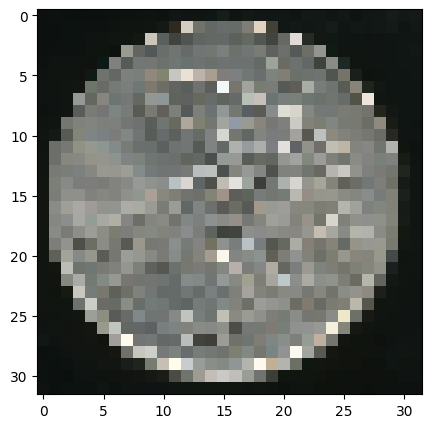

In [ ]:


import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile

print("✅ Google Drive connected.")

# ------------------------------
# 2. Load Dataset
# ------------------------------
print("\n🔍 Loading dataset...")

# If your ZIP does NOT contain 'validation' folder, we'll create one
HAS_VAL = os.path.exists(os.path.join("/content/coin_dataset/coins/data/", "validation"))

if HAS_VAL:
    print("✅ Found 'validation' folder.")
    train_dir = os.path.join("/content/coin_dataset/coins/data/", "train")
    val_dir = os.path.join("/content/coin_dataset/coins/data/", "validation")
else:
    print("⚠️ No 'validation' folder. Using 20% of train for validation.")
    train_dir = os.path.join("/content/coin_dataset/coins/data/", "train")  # assume all data is in /train
    # We'll let image_dataset_from_directory handle validation split internally

# Load train dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    seed=42,
    validation_split=0.2 if not HAS_VAL else None,
    subset="training" if not HAS_VAL else None
)

# Load validation dataset
if HAS_VAL:
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode='int',
        seed=42
    )
else:
    val_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode='int',
        seed=42,
        validation_split=0.2,
        subset="validation"
    )

# Normalize to [0,1]
normalization = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))

# Optimize
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

# ------------------------------
# 3. Load Pre-trained Model & Modify
# ------------------------------
print("\n🔄 Loading CIFAR-10 pre-trained model...")

if not os.path.exists(PRETRAINED_MODEL_PATH):
    raise FileNotFoundError(f"Pre-trained model not found at: {PRETRAINED_MODEL_PATH}")

base_model = tf.keras.models.load_model(PRETRAINED_MODEL_PATH)
base_model.trainable = False

# Replace final layer
x = base_model.layers[-2].output
new_head = tf.keras.layers.Dense(NUM_COIN_CLASSES, activation=None, name='coin_logits')(x)
model = tf.keras.Model(inputs=base_model.input, outputs=new_head)

# ------------------------------
# 4. Train
# ------------------------------
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("\n🚀 Training classifier head...")
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ]
)

# ------------------------------
# 5. Save Results to Google Drive
# ------------------------------
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save model
model.save(os.path.join(OUTPUT_DIR, "coin_classifier_finetuned.h5"))

# Save TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(os.path.join(OUTPUT_DIR, "coin_classifier.tflite"), "wb") as f:
    f.write(tflite_model)

# ------------------------------
# 6. Demo Prediction
# ------------------------------
print("\n📸 Generating demo prediction...")

for images, labels in val_ds.take(1):
    img = images[0]
    true_label = labels[0].numpy()
    break

logits = model.predict(tf.expand_dims(img, 0), verbose=0)
pred = np.argmax(logits, axis=1)[0]
conf = tf.nn.softmax(logits)[0][pred].numpy()

coin_names = ['1000 Rials', '2000 Rials', '5000 Rials', '10000 Rials', '20000 Rials', '50000 Rials']

plt.figure(figsize=(5, 5))
plt.imshow(img.numpy())
plt.title(
    f"True: {coin_names[true_label]}\n"
    f"Pred: {coin_names[pred]} ({conf:.2f})",
    color='green' if pred == true_label else 'red'
)
plt.axis('off')
plt.tight_layout()

demo_path = os.path.join(OUTPUT_DIR, "demo_prediction.png")
plt.savefig(demo_path, dpi=150)
plt.show()

print(f"\n✅ All outputs saved to: {OUTPUT_DIR}")